# Social Media Sanctions and Misinformation Sharing

There has been a lot of discussions on politics and sanctions in social media. Specifically, people with conservative beliefs argue that they are more likely to be sanctioned on social media than those with more liberal beliefs.

If this happens, however, that may not necessarily be the result of different policies on behalf of the social media companies. It may simply be that people with conservative beliefs post online more questionable content, and so they are more likely to be sanctioned even with a completely neutral sanction policy.

In a [recent analysis in Nature](https://www.nature.com/articles/s41586-024-07942-8), Mohshen Moshel et al. investigated whether social media sanctions are politically biased or they are the result of differences in misinformation sharing between people of different political beliefs. The authors argue that that media sanctions are not politically biased. Social media users with conservative political beliefs are more likely to post questionable or misinformation material, and so they are more likely to be sanctioned. In this assignment, you will follow through some of Moshel et al.'s research.

You will use their data, available at [mosleh_et_al_data.csv](mosleh_et_al_data.csv).

---
> Eleni Kechrioti <br />
> Department of Informatics <br />
> Athens University of Economics and Business <br />
> p3210078@aueb.gr

## Introduction

The assignment is structured as follows to ensure clarity and ease of navigation:

- **Root Directory**:
  - **`differences_misinformation.ipynb`**: Jupyter Notebook file where the analysis is performed.
  - **`mosleh_et_al_data.csv`**: Contains the data we will use for our analysis.

Notice that the dataset is in the same folder, in the root directory as this notebook.

## Imports

We will use the libraries imported below. Make sure to have them installed or else install them with `pip install <library>`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

Let's load the data and see what we have.

In [2]:
politics_df = pd.read_csv(
    "mosleh_et_al_data.csv", delimiter=",", index_col=False
)

politics_df.shape

(9000, 42)

So our dataset contains of 9000 entries with 42 attributes (columns).

In [3]:
politics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   politics_sites2            9000 non-null   float64
 1   politics_sites1            9000 non-null   float64
 2   politics_followed          7965 non-null   float64
 3   lowqual_pr2019_crowd       8945 non-null   float64
 4   lowqual_pr2019_fc          8945 non-null   float64
 5   lowqual_afm                8998 non-null   float64
 6   lowqual_mbfc               8999 non-null   float64
 7   lowqual_lasser2019         8999 non-null   float64
 8   suspended                  9000 non-null   int64  
 9   politics_hashtag           9000 non-null   int64  
 10  lowqual_pr2019_crowdrep    8945 non-null   float64
 11  num_followers              9000 non-null   int64  
 12  num_friends                9000 non-null   int64  
 13  tweets_in_2wk              9000 non-null   int64

As we can see from the info above, many values are missing from some attributes like `politics_followed`, `lowqual_pr2019_crowd`and more. Let's see a sample of the dataset to understand it more.

In [4]:
politics_df.sample(3)

,politics_sites2,politics_sites1,politics_followed,lowqual_pr2019_crowd,lowqual_pr2019_fc,lowqual_afm,lowqual_mbfc,lowqual_lasser2019,suspended,politics_hashtag,...,valence_neg,valence_neu,valence_pos,politics_sites2_ideo_std,hashtag_ideo_std,barbera_std,politics_sites1_std,repeated_tweet_count,freq_pr_1h,bad_domain_count
4108,-0.094475,-0.359427,-1.060903,0.571916,0.300595,0.183472,0.294885,0.291667,0,0,...,0.070450,0.84055,0.088980,0.269699,0.0,0.351822,48,NaN,1,2
2608,-0.211458,-0.973164,-1.025424,0.662257,0.411830,0.209679,0.302416,0.350000,0,0,...,0.066420,0.82546,0.108115,0.274889,0.0,0.577074,61,72.0,13,10
5378,0.529861,1.171390,1.951610,0.736499,0.765553,0.444114,0.531559,0.827703,0,1,...,0.066405,0.84300,0.090595,0.333017,0.0,0.602310,51,285.0,53,19


## Twitter Suspensions after the 2020 Election

Show, using crosstabulation, that accounts that shared `#Trump2020` during the election were about 4.4 times more likely to be subsequently suspended than the accounts that shared `#VoteBidenHarris2020` (relevant columns: `politics_hashtag` and `suspended`). Then perform a $\chi^2$ test on the contingency table and explain the results.

In [5]:
crosstab = pd.crosstab(politics_df['politics_hashtag'], politics_df['suspended'])
crosstab

suspended,0,1
politics_hashtag,,
0,4295,200
1,3623,882


We used the `crosstab` function of python *pandas* for the crosstabulation. Above we can see the results but let's make them prettier to understand it better.

We will rename the `0` and `1` to `No` and `Yes` in the suspended correspondenly, and the hashtags `#VoteBidenHraris2020` and `#Trump2020` in the politics_hashtag.

In [6]:
crosstab.index.name = 'politics_hashtag'
crosstab.columns.name = 'suspended'

# Rename indices and columns
renamed_data = crosstab.rename(index={0: '#VoteBidenHarris2020', 1: '#Trump2020'}, columns={0: 'No', 1: 'Yes'})

renamed_data

suspended,No,Yes
politics_hashtag,,
#VoteBidenHarris2020,4295,200
#Trump2020,3623,882


Now that it is more clear let's make some observations. We can see that a bit more was used the `#VoteBidenHarris` hashtag instead of the `#Trump2020`. But what seems more interesting is the fact that a lot more accounts were suspended if they used the `#Trump2020` hashtag, which by eye it looks like it's almost 4 times bigger the amount of those suspended using the `#VoteBidenHarris2020` hashtag. Let's calculate it and see if we are correct.

In [7]:
# Suspension rates
suspension_rates = crosstab[1] / crosstab.sum(axis=1)

# Relative likelihood: Trump2020 suspension rate / BidenHarris2020 suspension rate
relative_likelihood = suspension_rates[1] / suspension_rates[0]

print(f"Suspension rate for #Trump2020: {suspension_rates[1]:.2f}")
print(f"Suspension rate for #VoteBidenHarris2020: {suspension_rates[0]:.2f}")
print(f"Relative likelihood of suspension: {relative_likelihood:.2f}")


Suspension rate for #Trump2020: 0.20
Suspension rate for #VoteBidenHarris2020: 0.04
Relative likelihood of suspension: 4.40


What it says above is that **4%** of the accounts that used the `#VoteBidenHarris2020` is likely to get suspended, while **20%** of the accounts that used the `#Trump2020` is likely to get suspended. The relative likelihood tells us that the accounts that used the Trump hashtag are 4.4 times more likely to get suspended.

Let's perform now the $\chi^2$ test on the contingency table and get more information.

In [8]:
from scipy.stats import chi2_contingency

# Chi-square test
chi2, p, dof, expected = chi2_contingency(crosstab)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)


Chi-square statistic: 485.4671
p-value: 0.0000
Degrees of freedom: 1
Expected frequencies:
[[3954.60111111  540.39888889]
 [3963.39888889  541.60111111]]


A **$\chi^2$ test** conducted on a contingency table can test whether or not a **relationship exists** between variables. These effects are defined as relationships between rows and columns.

Let's talk about the results from the chi squared test.
* Chi-square statistic tell us how much observed frequencies (from the crosstabulation) deviate from the expected frequencies (the data if they were independent). The number `485.4671` is very high and that indicates that there is a stronger association between the variables.
* p-value indicates the probability of observing the data assuming the null hypothesis is true, helping to determine the strength of the evidence against the null hypothesis. The **null hypothesis** states that there is no relation between the variables **(which assumes no association between the hashtag used and suspension status)**. Here the p-value is significantly small `0` and it is below that the common significant value of `0.05`, thus making us **reject** the null hypothesis. The rejection of the null hypothseis *means* that there is a significant relationship.
* The expected frequencies are simply the numbers we would see in the crosstabulation above if the data were independent.

## Distributions of Relative Frequency of Low Quality

Plot the distributions of low-quality sharing as determined by eight professional fact-checkers (column `lowqual_pr2019_fc`), grouped by `politics_hashtag`. The $x$-axis should be standardized using z-scores. The distributions should look like the following figure.

### Z-Score

A **Z-score** (also known as the **standard score**) is a statistical measure that describes how many standard deviations a data point is from the mean of the dataset. The formula for calculating the Z-score is:

$$ Z = \frac{X - \mu}{\sigma} $$

Where:
- \( X \) is the data point.
- \( \μ \) is the mean of the data.
- \( \σ \) is the standard deviation of the data.

Let's calculate it as said, plot it and discuss the results.

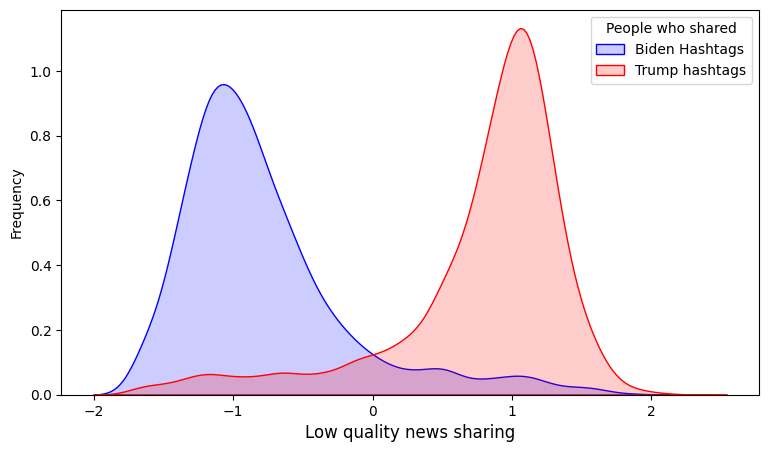

In [9]:
mean = politics_df['lowqual_pr2019_fc'].mean()
std = politics_df['lowqual_pr2019_fc'].std()

#           z                 =             X                    -   μ    / σ
politics_df['lowqual_zscore'] = (politics_df['lowqual_pr2019_fc'] - mean) / std


# Plot the distributions grouped by 'politics_hashtag'
plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=politics_df[politics_df['politics_hashtag'] == 0],
    x='lowqual_zscore',
    fill=True,
    color='blue',
    alpha=0.2,
    label='Biden Hashtags'
)

# Red curve for the second group
sns.kdeplot(
    data=politics_df[politics_df['politics_hashtag'] == 1],
    x='lowqual_zscore',
    fill=True,
    color='red',
    alpha=0.2,
    label='Trump hashtags'
)

plt.xlabel("Low quality news sharing", fontsize=12)
plt.ylabel("Frequency", fontsize=10)
plt.legend(title="People who shared", fontsize=10)
plt.grid(False)
plt.show()

The x-axis is the standardized z-scores we calculated. The y-axis is the relative frequency, such that the area under each curve sums up to 1. It shows that values are highly concetrated in certain areas, here around **-1** and **1** points for each curve. 

The higher the value is on x-axis the lower the quality on news-sharing is. So we can see that people who shared **Biden hashtags** are more concentrated around the -1 on x-axis, meaning that those people shared news from good quality sources, and only a small amount of them shares from lower quality. You can see that the blue curve slowly falls after the **-1** point. On the other hand, we can see that people who shared **Trump hashtags** are more concentrated around the 1 on x-axis, where the quality of the news sharing is considered lower.

<img src="fig_1.svg"/>

Having done, that, proceed to do the same with low-quality sharing as determined by crowdsourcing from 971 participants from the USA (column `lowqual_pr2019_crowd`). The distributions should look like the following figure.

So we perform the same code and mathematics to see the distribution determined by crowdsourcing from 971 participants from the USA (column `lowqual_pr2019_crowd`).

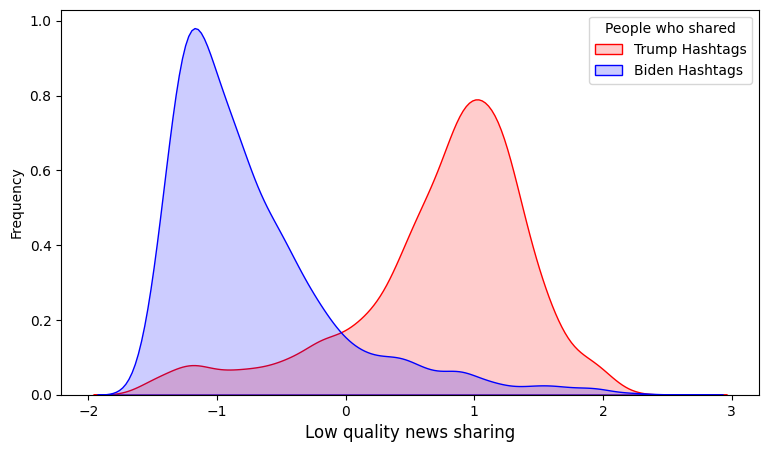

In [10]:
mean = politics_df['lowqual_pr2019_crowd'].mean()
std = politics_df['lowqual_pr2019_crowd'].std()

politics_df['lowqual_zscore_crowd'] = (politics_df['lowqual_pr2019_crowd'] - mean) / std

# Plot the distributions grouped by 'politics_hashtag'
plt.figure(figsize=(9, 5))

# Red curve for the second group
sns.kdeplot(
    data=politics_df[politics_df['politics_hashtag'] == 1],
    x='lowqual_zscore_crowd',
    fill=True,
    color='red',
    alpha=0.2,
    label='Trump Hashtags'
)

sns.kdeplot(
    data=politics_df[politics_df['politics_hashtag'] == 0],
    x='lowqual_zscore_crowd',
    fill=True,
    color='blue',
    alpha=0.2,
    label='Biden Hashtags'
)

plt.xlabel("Low quality news sharing", fontsize=12)
plt.ylabel("Frequency", fontsize=10)
plt.legend(title="People who shared", fontsize=10)
plt.grid(False)
plt.show()

The distributions are very similar to the ones we made before, so we can make the same observations here. 

But there is something small that is worth mentioning. We can see that both the red curve and the blue continues after the **2** on x-axis reaching almost **3**. Typically, z-scores below -2 and above 2 are considered outliers. Outliers indicate special events, errors in data handling and rare events. As we said before the higher the value on x the lower the quality, menaning that at 3 the quality of the news sharing is very very low and that is kinda rare for democrats based on the results we discussed previous and now. 

## Low-quality News Sharing on Twitter

We will proceed to examine low-quality news sharing on Twitter on a more quantitave manner, using the t-test. In particular, we will use the t-test based on groups of users depending on their `politics_hashtag` and various assessments of low-quality news sharing. We will quantify the effect size of the t-test using Cohen's $d$ and Hedges' $g$.

Cohen's $d$ is defined as the difference between two means divided by a standard deviation for the data, i.e.:

$$ d = \frac{\bar{x}_{1} - \bar{x}_{2}}{s} $$

$s$, the pooled standard deviation for two independent samples is defined as:

$$ s=\sqrt{\frac{(n_{1}-1)s_{1}^{2}+(n_{2}-1)s_{2}^{2}}{n_{1}+n_{2}-2}} $$

where $n_1$, $n_2$ is the size of each sample and the variance of $s_1$ is defined as:

$$ s_{1}^{2}=\frac{1}{n_{1}-1} \sum _{i=1}^{n_{1}}(x_{1,i}-{\bar {x}}_{1})^{2} $$

with the variance of $s_2$ defined similarly. The values of Cohen's $d$ can be interpreted as follows:

| Effect Size | $d$  |
|-------------|------|
| Very small  | 0.01 |
| Small	      | 0.20 |
| Medium	  | 0.50 |
| Large	      | 0.80 |
| Very large  | 1.20 |
| Huge        | 2.00 |

Hedges' $g$ corrects Cohen's $d$ for bias in small sample sizes and is defined as:

$$ \Bigg(1 - \frac{3}{4  (n_1 + n_2) - 9)}\Bigg)d $$

You will perform a t-test statistic and report Cohen's $d$ and Hedges' $g$ for the following, grouped by `politics_hashtag`.

* `lowqual_pr2019_fc` (sites rated by fact-checkers)
* `lowqual_afm` (sites rated by Ad Fontes media, <https://adfontesmedia.com/>)
* `lowqual_mbfc` (sites rated by Media Bias/Fact Check, <https://mediabiasfactcheck.com/>)
* `lowqual_lasser2019` (sites rated by Laser et al., https://doi.org/10.1093/pnasnexus/pgac186)
* `lowqual_pr2019_crowd` (sites rated by crowdsourcing 971 participants from the USA)
* `lowqual_pr2019_crowdrep` (sites rated by the republicans among the 971 participants of above)

### Effect Size Calculation: Cohen's d and Hedges' g

This function calculates two common measures that help us understand the size of the difference between two groups:

1. **Cohen's d**: Measures the difference between the two group means in terms of standard deviations.
2. **Hedges' g**: A slightly adjusted version of Cohen's d that corrects for small sample sizes.

#### Steps:
1. **Calculate the Means**: The average values of the two groups (`group1` and `group2`).
2. **Calculate the Standard Deviations**: Measures how spread out the values are within each group.
3. **Calculate the Pooled Standard Deviation**: Combines the standard deviations of both groups into one value, which helps standardize the difference.
4. **Cohen's d**: The difference between the means of the two groups, divided by the pooled standard deviation.
5. **Hedges' g**: A correction to Cohen's d, especially for small sample sizes, to make it less biased.


In [11]:
def effect_sizes(group1, group2):
    # Means and standard deviations
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    n1, n2 = len(group1), len(group2)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    # Cohen's d
    cohen_d = (mean1 - mean2) / pooled_std
    
    # Hedges' g correction factor
    correction = 1 - (3 / (4 * (n1 + n2) - 9))
    hedges_g = cohen_d * correction
    
    return cohen_d, hedges_g

We will need to drop the null values in order to perform the test.

In [12]:
variables = [
    'lowqual_pr2019_fc',
    'lowqual_afm',
    'lowqual_mbfc',
    'lowqual_lasser2019',
    'lowqual_pr2019_crowd',
    'lowqual_pr2019_crowdrep'
]

pd = politics_df.copy()
results = []


# Perform t-tests and calculate effect sizes
for var in variables:
    # Split data by 'politics_hashtag'
    group1 = pd[pd['politics_hashtag'] == 1][var].dropna()
    group2 = pd[pd['politics_hashtag'] == 0][var].dropna()
    
    # Perform t-test
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    
    # Compute effect sizes
    cohen_d, hedges_g = effect_sizes(group1, group2)
    
    # Store results
    results.append({
        'Variable': var,
        't-statistic': t_stat,
        'p-value': p_val,
        "Cohen's d": cohen_d,
        "Hedges' g": hedges_g
    })

Let's see the results.

In [15]:
results = pd.DataFrame(results)
results

,Variable,t-statistic,p-value,Cohen's d,Hedges' g
0,lowqual_pr2019_fc,119.246476,0.0,2.521188,2.520977
1,lowqual_afm,102.711200,0.0,2.164878,2.164698
2,lowqual_mbfc,97.584148,0.0,2.057540,2.057369
3,lowqual_lasser2019,102.679384,0.0,2.163831,2.163650
4,lowqual_pr2019_crowd,102.501955,0.0,2.166782,2.166601
5,lowqual_pr2019_crowdrep,61.083019,0.0,1.291464,1.291356


### What do they say?

- **t-statistic**: Measures the difference between the groups relative to their variability. High values (ranging from 61 to 119) indicate that the group differences are much larger than the variability within the groups.
  
- **p-value**: Indicates the probability of observing the results by chance. All p-values are 0.0, meaning the differences are statistically significant and not likely due to random chance. A smaller p-value suggests stronger evidence that the observed difference is real.

- **Cohen's d**: Measures the effect size, or the magnitude of the difference between groups, in standard deviation units. Values range from 1.29 to 2.52, indicating **very large to huge effects**.

- **Hedges' g**: Similar to Cohen's d but with a correction for small sample sizes. The values are close to Cohen's d, also indicating **very large effects**.

### Summary
- The differences between the groups are **statistically significant** (p = 0.0).
- The **effect size** is **very large** (Cohen's d and Hedges' g values above 1.2).
- These results suggest meaningful, significant differences between the groups for each variable.


### Sharing Lower-quality News Sources and Conservative Ideology

To see if there is a correlation between lower-quality news sources and conservative ideology, you will perform pairwise correlations between, on the one hand:

 * `lowqual_pr2019_fc`
 * `lowqual_lasser2019`
 * `lowqual_mbfc`
 * `lowqual_afm`
 * `lowqual_pr2019_crowd`
 * `lowqual_pr2019_crowdrep`

and on the other hand:

 * `politics_followed` (political ideology estimated on the basis of Twitter accounts user followed)
 * `politics_hashtag`
 * `politics_sites1` (political ideology estimated on the basis of the news sites the users share, <https://doi.org/10.1126/science.aau2706>)
 * `politics_sites2` (political ideology estimated on the basis of the news sites ther users share, <https://doi.org/10.31219/osf.io/ch8gj>)


We will devide the columns needed for the x-axis and y-axis in the `x_vars` and `y_vars` variables correspondenly. Then using the `corr()` function we can calculate the correlation matrix for those values. 

### Why `.corr()`?

The .corr() method in pandas computes the Pearson correlation coefficient by default. Pearson's correlation measures the linear relationship between two variables, providing a value between -1 and 1:
* +1 means a perfect positive correlation.
* -1 means a perfect negative correlation.
* 0 means no linear relationship.

We can then use then the calculated matrix to create a correlation heatmap, where each cell in the matrix represents the correlation between two variables.

In [16]:
y_vars = [
    'lowqual_pr2019_fc',
    'lowqual_lasser2019',
    'lowqual_mbfc',
    'lowqual_afm',
    'lowqual_pr2019_crowd',
    'lowqual_pr2019_crowdrep'
]

x_vars = [
    'politics_followed',
    'politics_hashtag',
    'politics_sites1',
    'politics_sites2'
]

# Calculate the correlation matrix between the two sets of variables
corr_matrix = politics_df[y_vars + x_vars].corr()

# Extract the submatrix of interest (correlations between Y and X)
corr_y_x = corr_matrix.loc[y_vars, x_vars]

After we calculated that, all that is left to do is to plot it into a heatmap to visualize it and understand it better.

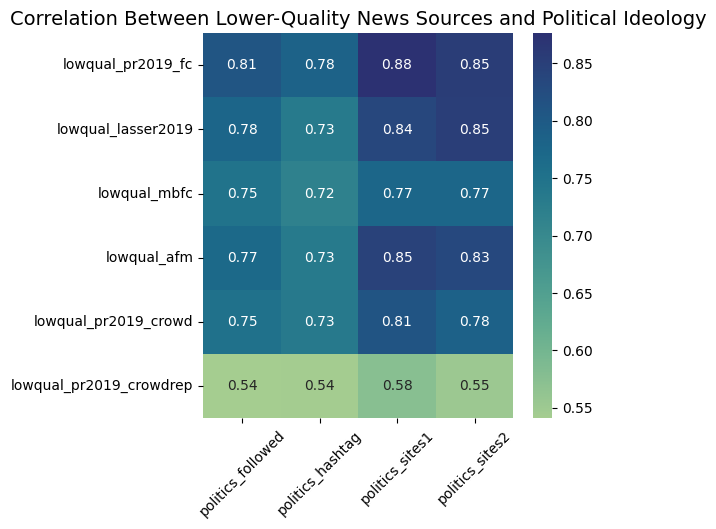

In [17]:
plt.figure(figsize=(5, 5))
sns.heatmap(
    corr_y_x,
    annot=True,
    cmap="crest",
    fmt=".2f"
)
plt.title("Correlation Between Lower-Quality News Sources and Political Ideology", fontsize=14)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10, rotation=0)
plt.show()

### What a Correlation Heatmap Tells US

- **Strength of relationships**: Colors indicate correlation strength. Strong positive correlations are dark (e.g., dark blue). Weak correlations are lighter.
  
- **Identifying trends**: Helps identify variables that move together (positive correlation) or in opposite directions (negative correlation).

- **Multivariable relationships**: Compares multiple variables at once, showing how they relate to each other in a single plot.

- **Data insights**: Reveals which variables are closely related, potentially highlighting those to combine or remove due to multicollinearity.

- **Potential outliers or anomalies**: Unusual correlations may indicate data issues, like outliers or errors.



### What do you see?

We can see that the values are above **0.5** which means that there is a positive correlation between these variables. Some of them, which we can identify by the dark blue color (bigger than 0.85) have a very strong correlation. With this heatmap we can identify trends, meaning which variables are strongly related to each other and tend to move in the same direction. That is what we see happening for example with `lowqual_pr2019_fc` and `politics_sites1`. This high number of correlation (0.88) can also tell us that they might be usefull to combine for our analysis.

## News Sharing Can Help Explain Suspension, Using Single Predictors

You will use the following predictors to predict whether a user was suspended or not:

  * `politics_hashtag`
  * `politics_sites1`
  * `politics_sites2`
  * `politics_followed`
  * `lowqual_afm`
  * `lowqual_mbfc`
  * `lowqual_lasser2019`
  * `lowqual_pr2019_fc`
  * `lowqual_pr2019_crowd`

The predictions will be with a probit model. The probit model is an alternative to logit, but while the latter uses the logit as the *link function*, the probit model uses the inverse of the cumulative distribution function (CDF) of the standard normal distribution (denoted as $\Phi^{-1}$) as the link function. Mathematically:

$$ \Phi^{-1}(P(Y = 1 | X)) = X\beta $$

where $P(Y = 1  | X)$ is the probability of the event occurring, $X$ represents the independent variables, and $\beta$ is the vector of coefficients.

The predictions will be evaluated with the AUC of the ROC curve. To get confidence intervals, repeat each prediction 100 times by using the boostrap method. 

Print the AUC and the confidence intervals in a table. Then use them to plot all your evaluations and the confidence intervals in a barchart like the following:


First we will need to devide the predictors and the target where the prediction is to be made. After that we will keep only the data we need, and we will clean it from missing values.

In [ ]:
predictors = [
    'politics_hashtag', 'politics_sites1', 'politics_sites2', 'politics_followed',
    'lowqual_afm', 'lowqual_mbfc', 'lowqual_lasser2019', 'lowqual_pr2019_fc', 'lowqual_pr2019_crowd'
]
target = 'suspended'

# Select predictors and target
X = politics_df[predictors]
y = politics_df[target]

# Step 2: Clean the data by removing rows with missing values in either X or y
# Combine X and y into a single DataFrame to drop rows with missing values in either
df_combined = pd.concat([X, y], axis=1)

# Replace infinite values with NaN and drop rows with any NaN values
df_cleaned = df_combined.dropna()

# Separate cleaned predictors (X) and target (y)
X_clean = df_cleaned[predictors]
y_clean = df_cleaned[target]

# Add a constant to X (for the intercept in the Probit model)
X_clean = sm.add_constant(X_clean)

# Step 3: Fit the Probit model
n_iterations = 100
results = []

# Define classes for the predictors
class_1 = ['politics_hashtag', 'politics_sites1', 'politics_sites2', 'politics_followed']  # Political orientation
class_2 = ['lowqual_afm', 'lowqual_mbfc', 'lowqual_lasser2019', 'lowqual_pr2019_fc', 'lowqual_pr2019_crowd']  # Low-quality news sharing

In [19]:
# Loop through predictors
for predictor in predictors:
    # Only use one predictor at a time
    X_single = X_clean[[predictor]]
    
    # Bootstrap AUC calculations
    bootstrap_aucs = []

    for i in range(n_iterations):
        # Bootstrap resampling
        X_resampled, y_resampled = resample(X_single, y_clean, n_samples=len(X_clean), random_state=i)
        
        # Fit the Probit model on the resampled data
        model_resampled = sm.Probit(y_resampled, sm.add_constant(X_resampled))
        result_resampled = model_resampled.fit(disp=0)
        
        # Get predictions and calculate AUC
        predictions_resampled = result_resampled.predict(sm.add_constant(X_resampled))
        auc_resampled = roc_auc_score(y_resampled, predictions_resampled)
        bootstrap_aucs.append(auc_resampled)

    # Calculate the AUC for the original data
    model = sm.Probit(y_clean, sm.add_constant(X_single))
    result = model.fit(disp=0)
    predictions = result.predict(sm.add_constant(X_single))
    auc = roc_auc_score(y_clean, predictions)
    
    # Confidence intervals from bootstrap
    auc_lower = np.percentile(bootstrap_aucs, 5)
    auc_upper = np.percentile(bootstrap_aucs, 95)
    
    # Append the results for this predictor
    results.append({
        'Predictor': predictor,
        'AUC': auc,
        'CI Lower': auc_lower,
        'CI Upper': auc_upper,
        'Class': 'Political orientation' if predictor in class_1 else 'Low-quality news sharing'
    })

Let's see the results. 

In [ ]:
auc_results = pd.DataFrame(results)
auc_results

,Predictor,AUC,CI Lower,CI Upper,Class
0,politics_hashtag,0.698174,0.685376,0.710440,Political orientation
1,politics_sites1,0.716388,0.705518,0.732541,Political orientation
2,politics_sites2,0.721960,0.708917,0.733372,Political orientation
3,politics_followed,0.715405,0.698469,0.730344,Political orientation
4,lowqual_afm,0.734487,0.720561,0.748129,Low-quality news sharing
5,lowqual_mbfc,0.723133,0.709243,0.736809,Low-quality news sharing
6,lowqual_lasser2019,0.722199,0.711242,0.735872,Low-quality news sharing
7,lowqual_pr2019_fc,0.715155,0.702695,0.728900,Low-quality news sharing
8,lowqual_pr2019_crowd,0.701732,0.687446,0.715445,Low-quality news sharing


We can see that all predictors show moderate predictive performance, with AUC values ranging from approximately `0.698` to `0.734`. This indicates that no single variable is highly predictive of suspension on its own.

Also the confidence intervals (CI) for all predictors are relatively narrow, indicating that the AUC estimates are reliable.

Low-quality news sharing predictors appear to be more indicative of user suspension than political orientation predictors. That is because these predictors have slightly higher AUCs, suggesting that sharing low-quality news is more strongly associated with suspension.

However, since the AUC values are all below 0.8, these predictors are moderately predictive at best and likely need to be combined or used in conjunction with other factors for more accurate predictions.

Let's rename the predictors and plot a diagram for better visualizations.

In [21]:

# Create a dictionary with current column names as keys and new names as values
replace_names = {
    'politics_hashtag': 'Hashtag\nshared',
    'politics_sites1': 'News\nsites\nshared 1',
    'politics_sites2': 'News\nsites\nshared 2',
    'politics_followed': 'Accounts\nfollowed',
    'lowqual_afm': 'AFM\nratings',
    'lowqual_mbfc': 'MBFC\nratings',
    'lowqual_lasser2019': 'Lasser\nratings',
    'lowqual_pr2019_fc': 'Fact-\nchecker\nratings',
    'lowqual_pr2019_crowd': 'Layperson\nratings'
}

# Rename the columns
auc_results['Predictor'] = auc_results['Predictor'].replace(replace_names)

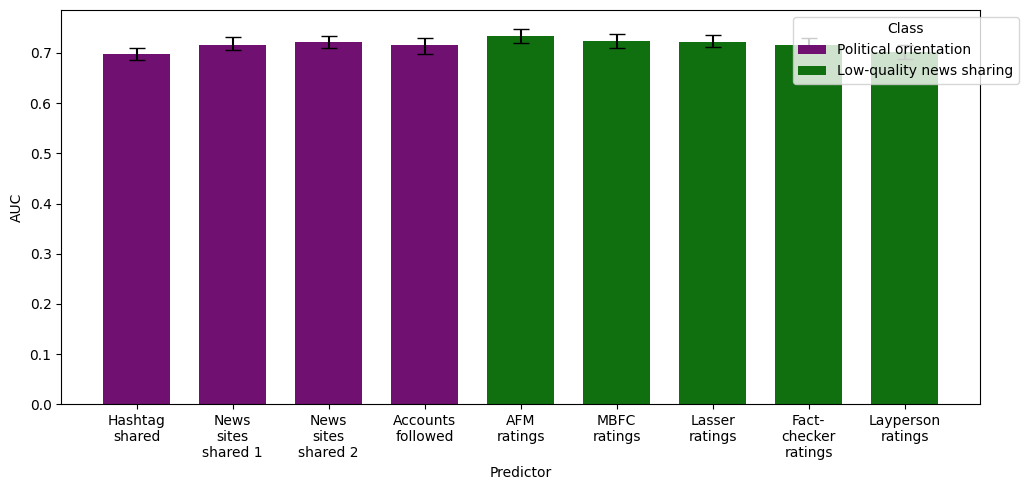

In [ ]:
Plotting the results as a bar chart
plt.figure(figsize=(10, 5))

# Define colors for the classes
color_map = {'Political orientation': 'purple', 'Low-quality news sharing': 'green'}

# Create the bar plot using seaborn, colored by the class
sns.barplot(x='Predictor', y='AUC', data=auc_results, hue='Class', palette=color_map, dodge=False, width=0.7)

# Adding error bars for the confidence intervals
plt.errorbar(
    x=range(len(auc_results)), 
    y=auc_results['AUC'], 
    yerr=[auc_results['AUC'] - auc_results['CI Lower'], auc_results['CI Upper'] - auc_results['AUC']], 
    fmt='none', 
    c='black', 
    capsize=6
)

# Set plot labels and title
plt.xticks(rotation=0, ha='center')
plt.ylabel('AUC')
plt.tight_layout()
plt.legend(title="Class", loc="upper right", bbox_to_anchor=(1.05, 1))
plt.show()

## News Sharing Can Help Explain Suspension, Using Multiple Predictors

You will also use multiple regression models to predict and explain suspension. 

Start by filing in missing values in your data by using the column mean. Then log transform, base 10, the variables that are related to Tweeter metrics, i.e.:

* `repeated_tweet_count` to `log_repeated_tweet_count`
* `freq_pr_1h` (maximum frequency of primary tweets in an hour) to `log_freq_pr_1h`
* `num_followers` to `log_num_followers`
* `num_friends` to `log_num_friends`

Introduce an additional variable, `log_num_fol`, which should the be base 10 logarithm of `num_friends` over `num_followers` ratio. To prevent out of domain errors, add 1 to each variable when using it in the transforms.

In [5]:
politics_df = politics_df.fillna(politics_df.mean())

# Step 2: Log-transform the specified variables
politics_df['log_repeated_tweet_count'] = np.log10(politics_df['repeated_tweet_count'] + 1)
politics_df['log_freq_pr_1h'] = np.log10(politics_df['freq_pr_1h'] + 1)
politics_df['log_num_followers'] = np.log10(politics_df['num_followers'] + 1)
politics_df['log_num_friends'] = np.log10(politics_df['num_friends'] + 1)

# Step 3: Compute log_num_fol
politics_df['log_num_fol'] = np.log10(
    (politics_df['num_friends'] + 1) / (politics_df['num_followers'] + 1)
)

# Display the transformed DataFrame
politics_df.sample(3)

,politics_sites2,politics_sites1,politics_followed,lowqual_pr2019_crowd,lowqual_pr2019_fc,lowqual_afm,lowqual_mbfc,lowqual_lasser2019,suspended,politics_hashtag,...,barbera_std,politics_sites1_std,repeated_tweet_count,freq_pr_1h,bad_domain_count,log_repeated_tweet_count,log_freq_pr_1h,log_num_followers,log_num_friends,log_num_fol
3266,0.544312,0.834315,1.737335,0.715181,0.735429,0.467072,0.549302,0.763093,0,1,...,0.801090,1038,98.0,36,253,1.995635,1.568202,3.143639,3.441381,0.297742
953,-0.117447,-0.790667,-1.555694,0.539180,0.216227,0.138201,0.297365,0.334302,0,0,...,0.259218,81,31.0,11,0,1.505150,1.079181,0.000000,2.298853,2.298853
8972,0.321725,1.316365,1.609266,0.705343,0.712857,0.467707,0.555268,0.568647,1,1,...,1.023988,217,109.0,43,11,2.041393,1.643453,3.487280,3.698449,0.211169


To reduce the effect of outliers, you will [winsorize](https://en.wikipedia.org/wiki/Winsorizing) the data. Winzorize from both sides at the top 1% the following variables:

* `valence_neg`
* `valence_neu`
* `valence_pos`
* `barbera_std`
* `politics_sites1_std`
* `politics_sites2_ideo_std`

The `valence_*`, variables were calculated using VADER (<https://doi.org/10.1609/icwsm.v8i1.14550>). The `barbera_std` variable was calculated based on the work of Barbera et al. (<https://doi.org/10.1177/0956797615594620>).

In [6]:
columns_to_winsorize = [
    'valence_neg', 'valence_neu', 'valence_pos', 
    'barbera_std', 'politics_sites1_std', 'politics_sites2_ideo_std'
]

# Winsorize each column
for col in columns_to_winsorize:
    # Winsorize at the top 1% (both sides)
    politics_df[f"{col}_winsorized"] = stats.mstats.winsorize(politics_df[col], limits=(0.01, 0.01))

# Display the winsorized DataFrame
politics_df.sample(3)

,politics_sites2,politics_sites1,politics_followed,lowqual_pr2019_crowd,lowqual_pr2019_fc,lowqual_afm,lowqual_mbfc,lowqual_lasser2019,suspended,politics_hashtag,...,log_freq_pr_1h,log_num_followers,log_num_friends,log_num_fol,valence_neg_winsorized,valence_neu_winsorized,valence_pos_winsorized,barbera_std_winsorized,politics_sites1_std_winsorized,politics_sites2_ideo_std_winsorized
2959,0.341242,0.896303,1.882111,0.721090,0.721774,0.397643,0.532089,0.692105,0,1,...,1.431364,2.909021,3.247728,0.338707,0.056220,0.863020,0.080755,0.722226,61,0.329673
146,-0.248794,-1.250065,-1.131409,0.545078,0.253247,0.368444,0.341035,0.414062,0,0,...,1.255273,2.167317,2.478566,0.311249,0.081005,0.841260,0.077740,0.452094,42,0.350809
7188,0.353500,0.980472,1.863348,0.708205,0.741071,0.377917,0.496362,0.595745,0,1,...,1.230449,3.128399,3.297761,0.169361,0.050820,0.855215,0.093960,0.688006,36,0.295584


Winsorize the upper side of the following  variables at the top 1%:

* `moral_outrage`
* `rewire_abuse`
* `rewire_hate`
* `rewire_profanity`
* `rewire_violent`
* `rewire_sexually_explicit`
* `jigsaw_toxicity`
* `jigsaw_severe_toxicity`
* `jigsaw_idenity_attack`
* `jigsaw_insult`
* `jigsaw_profanity`
* `jigsaw_threat`

The `moral_outrage` variable was calculated based on the work of Brady et al. (<https://doi.org/doi:10.1126/sciadv.abe5641>). The `rewire_*` variables were calculated using the Rewire Online API (acquired by ActiveFence in 2023)., The `jigsaw_*` variables were calculated using the Google Jigsaw Perspective API (<https://jigsaw.google.com/>, <https://perspectiveapi.com/>).

In [7]:
columns_to_winsorize = [
    'moral_outrage', 'rewire_abuse', 'rewire_hate', 'rewire_profanity', 
    'rewire_violent', 'rewire_sexually_explicit', 'jigsaw_toxicity', 
    'jigsaw_severe_toxicity', 'jigsaw_idenity_attack', 'jigsaw_insult', 
    'jigsaw_profanity', 'jigsaw_threat'
]

# Winsorize the upper side at 1%
for col in columns_to_winsorize:
    # Winsorize with limit on upper side only
    politics_df[f"{col}_winsorized"] = stats.mstats.winsorize(politics_df[col], limits=(0, 0.01))

# Display the results
politics_df.sample(3)

,politics_sites2,politics_sites1,politics_followed,lowqual_pr2019_crowd,lowqual_pr2019_fc,lowqual_afm,lowqual_mbfc,lowqual_lasser2019,suspended,politics_hashtag,...,rewire_hate_winsorized,rewire_profanity_winsorized,rewire_violent_winsorized,rewire_sexually_explicit_winsorized,jigsaw_toxicity_winsorized,jigsaw_severe_toxicity_winsorized,jigsaw_idenity_attack_winsorized,jigsaw_insult_winsorized,jigsaw_profanity_winsorized,jigsaw_threat_winsorized
5365,-0.082071,-0.435172,0.411658,0.563409,0.280134,0.153800,0.375577,0.302885,0,0,...,0.026404,0.085,0.004701,0.010361,0.073731,0.006771,0.014573,0.040979,0.051700,0.014094
215,-0.230235,-0.790721,-0.656055,0.576439,0.217391,0.125573,0.304091,0.255435,0,0,...,0.056406,0.015,0.002609,0.000670,0.075434,0.005289,0.015863,0.048798,0.039734,0.016703
7567,0.474200,0.796013,1.534311,0.687394,0.704365,0.324631,0.496980,0.585106,0,1,...,0.062012,0.050,0.005256,0.005564,0.131713,0.008796,0.026777,0.088572,0.056927,0.020118


You will derive and use a single PCA component, `pc1_misinfo`, for low quality news sharing, that is, the variables:

* `lowqual_pr2019_fc`
* `lowqual_afm`
* `lowqual_lasser2019`
* `lowqual_mbfc`

Show the explained variance ratio. Then project the low quality news sharing dimensions to this new dimension.

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [9]:
# Columns to include in PCA
low_quality_columns = [
    'lowqual_pr2019_fc', 'lowqual_afm', 
    'lowqual_lasser2019', 'lowqual_mbfc'
]

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(politics_df[low_quality_columns])

# Fit PCA
pca = PCA(n_components=1)
pc1_misinfo = pca.fit_transform(scaled_data)

# Add the first principal component to the dataframe
politics_df['pc1_misinfo'] = pc1_misinfo

# Display explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Results
print("Explained Variance Ratio for pc1_misinfo:", explained_variance)
print("\nProjected Data (pc1_misinfo):\n", politics_df[['pc1_misinfo']])

Explained Variance Ratio for pc1_misinfo: [0.87255953]

Projected Data (pc1_misinfo):
       pc1_misinfo
0       -1.643266
1        3.919070
2       -2.290660
3       -1.643703
4        2.426475
...           ...
8995    -1.071716
8996     2.415044
8997    -1.187753
8998     2.355411
8999    -1.812329

[9000 rows x 1 columns]


### What does that tell us?

* Explained Variance Ratio: The first principal component (pc1_misinfo) explains `87.26%` of the variance, meaning it effectively captures the main pattern in the data.
* Projected Data: Each score indicates how much an observation aligns with the principal component:
    * Positive scores (e.g., 3.919070) show strong alignment with the pattern.
    * Negative scores (e.g., -2.290660) suggest the opposite direction.
* Implication: pc1_misinfo is a powerful summary of the dataset, making it suitable for dimensionality reduction or identifying key patterns. Observations with extreme scores may represent strong contributors or outliers.

We will work in the same way for the political orientation, getting a single PCA component, `pc1_politics`, for the variables:

* `politics_hashtag`
* `politics_followed`
* `politics_sites1`
* `politics_sites2`

Show the explained variance ratio and project the political orientation dimensions to this new dimension.

Introduce a new variable, `extremity`, which is the absolute value of the PCA component you got.

In [10]:
# Columns to include in PCA
political_orientation_columns = [
    'politics_hashtag', 'politics_followed',
    'politics_sites1', 'politics_sites2'
]

# Standardize the data
scaled_politics = scaler.fit_transform(politics_df[political_orientation_columns])

# Fit PCA
pca_politics = PCA(n_components=1)
pc1_politics = pca_politics.fit_transform(scaled_politics)

# Add the first principal component to the dataframe
politics_df['pc1_politics'] = pc1_politics

# Calculate extremity
politics_df['extremity'] = politics_df['pc1_politics'].abs()

# Display explained variance ratio
explained_variance_politics = pca_politics.explained_variance_ratio_

# Results
print("Explained Variance Ratio for pc1_politics:", explained_variance_politics)
print("\nProjected Data (pc1_politics and extremity):\n", politics_df[['pc1_politics', 'extremity']])

Explained Variance Ratio for pc1_politics: [0.87952937]

Projected Data (pc1_politics and extremity):
       pc1_politics  extremity
0        -1.841564   1.841564
1         2.264580   2.264580
2        -2.105501   2.105501
3        -1.836106   1.836106
4         2.648512   2.648512
...            ...        ...
8995     -1.222281   1.222281
8996      2.194894   2.194894
8997     -1.570926   1.570926
8998      1.961819   1.961819
8999     -1.956316   1.956316

[9000 rows x 2 columns]


* Explained Variance Ratio: The first principal component (pc1_politics) explains `87.95%` of the variance, indicating it captures the majority of the political orientation data's variability.
* Projected Data:
    * pc1_politics: Represents the primary pattern in political orientation data.
    * extremity: Reflects the absolute distance from the origin (magnitude of alignment with the pattern), directly derived from `pc1_politics`.
    * Positive and negative values in pc1_politics indicate direction, while extremity measures the intensity without considering direction.
* Implication: The high explained variance shows that pc1_politics effectively summarizes political orientation data. Observations with higher extremity scores are more extreme in their alignment with the political orientation patterns.

Also do the same for `log_num_followers`, `log_num_friends`, `log_num_fol`, producing `pc1_fol`.

In [11]:
# Columns to include in PCA
follower_columns = ['log_num_followers', 'log_num_friends', 'log_num_fol']

# Standardize the data
scaled_followers = scaler.fit_transform(politics_df[follower_columns])

# Fit PCA
pca_followers = PCA(n_components=1)
pc1_fol = pca_followers.fit_transform(scaled_followers)

# Add the first principal component to the dataframe
politics_df['pc1_fol'] = pc1_fol

# Display explained variance ratio
explained_variance_followers = pca_followers.explained_variance_ratio_

# Results
print("Explained Variance Ratio for pc1_fol:", explained_variance_followers)
print("\nProjected Data (pc1_fol):\n", politics_df[['pc1_fol']])

Explained Variance Ratio for pc1_fol: [0.70462969]

Projected Data (pc1_fol):
        pc1_fol
0     1.367920
1     0.691199
2     1.643654
3    -3.280269
4     0.580975
...        ...
8995 -0.793181
8996  1.933270
8997 -0.178827
8998  1.107122
8999 -0.164176

[9000 rows x 1 columns]


Regarding the harmful language variables, perform PCA for *three* components, `pc1_harmful_language`, `pc2_harmful_language`, `pc3_harmful_language`, on the winsorized data of:

* `rewire_abuse`
* `rewire_hate`
* `rewire_profanity`
* `rewire_violent`
* `rewire_sexually_explicit`
* `jigsaw_toxicity`
* `jigsaw_severe_toxicity`
* `jigsaw_idenity_attack`
* `jigsaw_insult`
* `jigsaw_profanity`
* `jigsaw_threat`

Why use three components instead of one in this case? Try to interpret each of the principal components.

In [12]:
# Variables for PCA
harmful_language_vars = [
    'rewire_abuse', 'rewire_hate', 'rewire_profanity', 'rewire_violent', 
    'rewire_sexually_explicit', 'jigsaw_toxicity', 'jigsaw_severe_toxicity', 
    'jigsaw_idenity_attack', 'jigsaw_insult', 'jigsaw_profanity', 'jigsaw_threat'
]

# Standardize the harmful language variables
scaled_harmful_language = scaler.fit_transform(politics_df[harmful_language_vars])

# Fit PCA for three components
pca_harmful = PCA(n_components=3)
harmful_pcs = pca_harmful.fit_transform(scaled_harmful_language)

# Add the components to the dataframe
politics_df['pc1_harmful_language'] = harmful_pcs[:, 0]
politics_df['pc2_harmful_language'] = harmful_pcs[:, 1]
politics_df['pc3_harmful_language'] = harmful_pcs[:, 2]

# Explained variance ratio
explained_variance_harmful = pca_harmful.explained_variance_ratio_

# Display results
print("Explained Variance Ratio for each component:", explained_variance_harmful)
pd.DataFrame(pca_harmful.components_, 
                                columns=harmful_language_vars,
                                index=['PC1', 'PC2', 'PC3'])

Explained Variance Ratio for each component: [0.52515474 0.16841465 0.10831252]


,rewire_abuse,rewire_hate,rewire_profanity,rewire_violent,rewire_sexually_explicit,jigsaw_toxicity,jigsaw_severe_toxicity,jigsaw_idenity_attack,jigsaw_insult,jigsaw_profanity,jigsaw_threat
PC1,0.318851,0.237502,0.251409,0.213447,0.115554,0.394565,0.333493,0.302300,0.389904,0.375143,0.262233
PC2,-0.394329,-0.324022,-0.203339,-0.208397,-0.040724,-0.139063,0.396456,0.438118,-0.084402,-0.031389,0.525840
PC3,-0.137272,-0.445428,0.405919,0.016597,0.712225,-0.072384,0.053886,-0.156135,-0.115381,0.236637,-0.092785


### What all of this means?

* PC1: 52.5% of the total variance is explained.
* PC2: 16.8% of the total variance is explained.
* PC3: 10.8% of the total variance is explained.

The first three principal components together explain 79.1% of the variance in the data, indicating that these components capture most of the underlying patterns.Loadings represent the correlation between the original variables and the principal components. Higher absolute values indicate a stronger relationship.

1. **PC1 (52.5% Variance)**
   - **High Positive Loadings:** `rewire_abuse`, `rewire_hate`, `rewire_profanity`, `jigsaw_toxicity`, `jigsaw_severe_toxicity`, `jigsaw_idenity_attack`, `jigsaw_insult`, `jigsaw_profanity`.
   - **Interpretation:** Represents a **general harmful language** factor. Variables related to abuse, hate, profanity, and toxicity strongly contribute to this component, indicating PC1 captures the overall level of harmful language.

2. **PC2 (16.8% Variance)**
   - **High Positive Loadings:** `jigsaw_threat`, `jigsaw_idenity_attack`.
   - **High Negative Loadings:** `rewire_abuse`, `rewire_hate`.
   - **Interpretation:** Captures a **specific aspect of harmful language**, focusing on **threats and identity attacks**. Negative loadings suggest an inverse relationship with general abusive language.

3. **PC3 (10.8% Variance)**
   - **High Positive Loadings:** `rewire_profanity`, `rewire_sexually_explicit`.
   - **Moderate Positive Loading:** `jigsaw_profanity`.
   - **Interpretation:** Represents a **dimension of explicit harmful language**, such as **profanity and sexually explicit content**, independent of general toxicity.

#### **Overall Implications**
- **Dominant Patterns:** PC1 is the most significant component, capturing the majority of the variance related to harmful language.
- **Distinct Dimensions:** PC2 and PC3 reveal additional, distinct dimensions of harmful language, such as threats and explicit content.
- **Data Simplification:** These principal components reduce the dataset's dimensionality while retaining most of the important information, aiding further analysis and visualization.


Return to producing a single PCA component, `pc1_valence`, for the winsorized data of the valence variables:

* `valence_neg`
* `valence_neu`
* `valence_pos`

In [13]:
# Define valence variables
valence_vars = ['valence_neg', 'valence_neu', 'valence_pos']

# Standardize the valence variables
scaled_valence = scaler.fit_transform(politics_df[valence_vars])

# Perform PCA for a single component
pca_valence = PCA(n_components=1)
valence_pc = pca_valence.fit_transform(scaled_valence)

# Add the first principal component to the dataset
politics_df['pc1_valence'] = valence_pc[:, 0]

# Explained variance ratio for the first component
explained_variance_valence = pca_valence.explained_variance_ratio_

# Output the explained variance
print("Explained Variance Ratio for pc1_valence:", explained_variance_valence[0])

# Display the PCA loadings (weights for each variable)
print("\nPCA Loadings:\n", pd.DataFrame(pca_valence.components_, 
                                       columns=valence_vars, 
                                       index=['PC1']))

Explained Variance Ratio for pc1_valence: 0.7060587786792157

PCA Loadings:
      valence_neg  valence_neu  valence_pos
PC1    -0.459652     0.686838    -0.563005


**PC1 (70.6% Variance)**
   - **Positive Loading:** `valence_neu` (neutral valence).
   - **Negative Loadings:** `valence_neg` (negative valence) and `valence_pos` (positive valence).
   - **Interpretation:** PC1 reflects a **contrast between neutral valence and the extremes of valence** (positive and negative). High PC1 scores indicate stronger neutrality, while low scores suggest a tendency toward polarized valence (either positive or negative).

#### **Overall Implications**
- **Dominant Pattern:** PC1 captures the key variation in valence, emphasizing the distinction between neutrality and polarization.
- **Data Simplification:** This principal component reduces the dimensionality of valence-related data, facilitating a clearer analysis of emotional tone in the dataset.

Before proceeding, normalize the independent variables by taking their z-scores. You will use the following z-scored independent variables (winsorized as stated above):

* `pc1_politics`
* `pc1_misinfo`
* `pc1_fol`,
* `pc1_harmful_language`
* `pc2_harmful_language`
* `pc3_harmful_language`
* `pc1_valence`
* `tweets_in_2wk`
* `botsentinel_score`
* `extremity`
* `w_moral_outrage`
* `liwc_political`
* `log_freq_pr_1h`
* `log_repeated_tweet_count`
* `barbera_std`
* `politics_sites1_std`
* `politics_sites2_ideo_std`

In [15]:
# List of variables to standardize
variables_to_zscore = [
    'pc1_politics', 'pc1_misinfo', 'pc1_fol', 'pc1_harmful_language',
    'pc2_harmful_language', 'pc3_harmful_language', 'pc1_valence',
    'tweets_in_2wk', 'botsentinel_score', 'extremity', 'moral_outrage_winsorized',
    'liwc_political', 'log_freq_pr_1h', 'log_repeated_tweet_count',
    'barbera_std', 'politics_sites1_std', 'politics_sites2_ideo_std'
]

# Z-score normalization
for var in variables_to_zscore:
    politics_df[f'z_{var}'] = (politics_df[var] - politics_df[var].mean()) / politics_df[var].std()

# Display a preview of the z-scored variables
politics_df[[f'z_{var}' for var in variables_to_zscore]].head()

,z_pc1_politics,z_pc1_misinfo,z_pc1_fol,z_pc1_harmful_language,z_pc2_harmful_language,z_pc3_harmful_language,z_pc1_valence,z_tweets_in_2wk,z_botsentinel_score,z_extremity,z_moral_outrage_winsorized,z_liwc_political,z_log_freq_pr_1h,z_log_repeated_tweet_count,z_barbera_std,z_politics_sites1_std,z_politics_sites2_ideo_std
0,-0.981765,-0.879541,0.940796,0.880698,-0.336090,-0.638104,-0.670707,-0.098518,-0.859963,0.092128,-0.113137,0.347534,0.997519,0.150317,0.952194,0.023291,0.011347
1,1.207281,2.097642,0.475376,0.456927,-0.838711,-1.518500,-1.201100,-0.487108,0.954376,0.846574,-0.708839,1.828790,0.824787,0.419389,-1.627910,5.848638,1.109847
2,-1.122474,-1.226052,1.130434,0.643958,-0.322426,-0.380223,-0.518340,-0.282215,-0.761891,0.562859,0.461938,0.244190,-1.562748,-1.768133,-0.639309,-0.365767,0.086119
3,-0.978855,-0.879775,-2.256027,0.832514,-0.483351,0.321435,-1.524247,-0.748523,-0.418637,0.082394,0.045179,-0.031392,0.956521,0.267464,-1.286334,-0.123920,0.237617
4,1.411961,1.298746,0.399569,-0.780635,0.108840,-0.563654,0.670519,-0.481052,1.150521,1.531316,0.553080,1.139833,-0.548828,-0.382301,-0.688005,-0.313191,0.387131


Carry out a probit regression to predict suspension.

Before going on to interpret your results, perform the [Bonferroni correction](https://en.wikipedia.org/wiki/Bonferroni_correction) and the [Holm-Bonferroni correction](https://en.wikipedia.org/wiki/Holm%E2%80%93Bonferroni_method) correction. The purpose of both of these tests is to reduce the likelihood of false positives (Type I errors) when conducting multiple statistical tests.

In the Bonferroni correction, a hypothesis is rejected with an ajustment to the significance level $\alpha$:

$$ p < \frac{\alpha}{m} $$

which means that the $p$ values are adjusted by:

$$ p' = p \times m $$

where $m$ is the number of tests.

The Bonferroni-Holm method is less conservative compared to Bonferroni. It sorts the $p$-values in ascending order and compares them to less stringent thresholds:

$$ p_i \le \frac{\alpha}{m - i + 1} $$ 

where $i$ is the $i$-th smallest $p$-value. Starting with the smallest $p$-value, hypotheses are rejected sequentially until a $p$-value fails to meet the threshold. That means that the $p$ values are adjusted by:

$$ \widetilde{p}_{(i)}=\max _{j\leq i}\left\{(m-j+1)p_{(j)}\right\}_{1}, \text{ where }p_{(j)}\text{ is the $j$-th smallest $p$-value and }\{x\}_{1}\equiv \min(x,1). $$

Holm-Bonferroni applies progressively smaller corrections as it moves through the sorted $p$-values, making it less conservative and less likely to fall into false negatives (Type II errors).

Based on the results, do you think that political orientation influences suspension?

Do the same analysis using logit regression.

In [16]:
# Define the dependent variable
y = politics_df['suspended']

# Define the independent variables
X = politics_df[
    [
        'z_pc1_politics', 'z_pc1_misinfo', 'z_pc1_fol', 'z_pc1_harmful_language',
        'z_pc2_harmful_language', 'z_pc3_harmful_language', 'z_pc1_valence',
        'z_tweets_in_2wk', 'z_botsentinel_score', 'z_extremity',
        'z_moral_outrage_winsorized', 'z_liwc_political', 'z_log_freq_pr_1h',
        'z_log_repeated_tweet_count', 'z_barbera_std', 'z_politics_sites1_std',
        'z_politics_sites2_ideo_std'
    ]
]

# Add a constant term for the intercept
X = sm.add_constant(X)

# Fit the Probit model
probit_model = sm.Probit(y, X).fit()

# Display summary
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.303742
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:              suspended   No. Observations:                 9000
Model:                         Probit   Df Residuals:                     8982
Method:                           MLE   Df Model:                           17
Date:                Sun, 08 Dec 2024   Pseudo R-squ.:                  0.1732
Time:                        16:28:05   Log-Likelihood:                -2733.7
converged:                       True   LL-Null:                       -3306.3
Covariance Type:            nonrobust   LLR p-value:                7.114e-233
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -1.4215      0.023    -61.269      0.000      

### What do you notice?
1. **Misinformation (z_pc1_misinfo):**  
   - **Coefficient = 0.2494, p < 0.001**  
   - **Effect:** Users with higher misinformation-related behavior scores are significantly more likely to be suspended. This suggests that misinformation is a strong determinant of suspension.  

2. **Harmful Language (z_pc1_harmful_language):**  
   - **Coefficient = 0.1393, p < 0.001**  
   - **Effect:** Increased use of harmful language substantially raises suspension odds. It underscores the platform's sensitivity to such language patterns.

3. **Tweeting Frequency (z_tweets_in_2wk):**  
   - **Coefficient = 0.3286, p < 0.001**  
   - **Effect:** A high number of tweets in a short period is the strongest predictor in the model, indicating that high activity levels are closely monitored and potentially flagged.

4. **Bot Sentinel Scores (z_botsentinel_score):**  
   - **Coefficient = 0.1799, p < 0.001**  
   - **Effect:** Higher bot-likeness scores are associated with increased suspension likelihood, emphasizing the platform’s focus on automated or suspicious activity.

Misinformation, harmful language, tweeting frequency, and bot scores are the most influential predictors of suspension, highlighting platform enforcement priorities against misinformation, harmful behavior, and automated activity.


In [80]:
# Extract p-values
p_values = probit_model.pvalues
m = len(p_values)  # Number of tests
alpha = 0.05       # Significance level

# Bonferroni correction
bonferroni_p = p_values * m
bonferroni_p = bonferroni_p.clip(upper=1)  # Cap adjusted p-values at 1


# Holm-Bonferroni correction
holm_p = []
sorted_indices = p_values.argsort()
for i, p in enumerate(p_values[sorted_indices]):
    adjusted_p = (m - i) * p
    holm_p.append(min(adjusted_p, 1))  # Ensure p-values do not exceed 1

# Restore original order
holm_p = pd.Series(holm_p, index=p_values.index[sorted_indices]).reindex(p_values.index)


C:\Users\eleni\AppData\Local\Temp\ipykernel_15780\3203226391.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i, p in enumerate(p_values[sorted_indices]):


In [81]:
# Fit the Logit model
logit_model = sm.Logit(y, X).fit()

# Extract p-values and apply Bonferroni and Holm-Bonferroni corrections
logit_p_values = logit_model.pvalues

# Bonferroni correction
logit_bonferroni_p = logit_p_values * m
logit_bonferroni_p = logit_bonferroni_p.clip(upper=1)

# Holm-Bonferroni correction
logit_holm_p = []
sorted_indices = logit_p_values.argsort()
for i, p in enumerate(logit_p_values[sorted_indices]):
    adjusted_p = (m - i) * p
    logit_holm_p.append(min(adjusted_p, 1))

logit_holm_p = pd.Series(logit_holm_p, index=logit_p_values.index[sorted_indices]).reindex(logit_p_values.index)


Optimization terminated successfully.
         Current function value: 0.304132
         Iterations 7


C:\Users\eleni\AppData\Local\Temp\ipykernel_15780\428737438.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i, p in enumerate(logit_p_values[sorted_indices]):


In [82]:
# Summary table of p-values for Probit and Logit models
summary_table = pd.DataFrame({
    'Variable': X.columns,
    'Probit P': probit_model.pvalues,
    'Probit Bonferroni P': bonferroni_p,
    'Probit Holm-Bonferroni P': holm_p,
    'Logit P': logit_model.pvalues,
    'Logit Bonferroni P': logit_bonferroni_p,
    'Logit Holm-Bonferroni P': logit_holm_p,
})

summary_table

,Variable,Probit P,Probit Bonferroni P,Probit Holm-Bonferroni P,Logit P,Logit Bonferroni P,Logit Holm-Bonferroni P
const,const,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
z_pc1_politics,z_pc1_politics,1.060829e-02,1.909492e-01,1.060829e-01,5.881273e-03,1.058629e-01,5.881273e-02
z_pc1_misinfo,z_pc1_misinfo,7.637162e-08,1.374689e-06,1.069203e-06,3.413392e-08,6.144106e-07,4.778749e-07
z_pc1_fol,z_pc1_fol,9.089719e-01,1.000000e+00,9.089719e-01,9.313925e-01,1.000000e+00,9.313925e-01
z_pc1_harmful_language,z_pc1_harmful_language,9.368537e-10,1.686337e-08,1.498966e-08,1.162416e-08,2.092350e-07,1.743625e-07
z_pc2_harmful_language,z_pc2_harmful_language,3.794242e-01,1.000000e+00,1.000000e+00,4.094096e-01,1.000000e+00,1.000000e+00
z_pc3_harmful_language,z_pc3_harmful_language,2.164152e-06,3.895474e-05,2.596983e-05,3.687955e-06,6.638319e-05,4.056750e-05
z_pc1_valence,z_pc1_valence,6.278900e-02,1.000000e+00,5.023120e-01,7.767558e-02,1.000000e+00,4.660535e-01
z_tweets_in_2wk,z_tweets_in_2wk,6.782984e-57,1.220937e-55,1.153107e-55,6.266722e-59,1.128010e-57,1.065343e-57
z_botsentinel_score,z_botsentinel_score,2.485094e-06,4.473170e-05,2.733604e-05,8.408626e-07,1.513553e-05,1.009035e-05


Does Political Orientation Influence Suspension?
Based on the results:

The raw p-value for pc1_politics is small, which is significant at the 0.05 level. This suggests a potential association between political orientation and suspension.
However, after applying Bonferroni correction, the adjusted p-value becomes 0.1911, which is no longer significant at the 0.05 threshold.
Using the Holm-Bonferroni correction, the adjusted p-value is 0.0899, which also does not meet the 0.05 level of significance, though it is closer than the Bonferroni result.

Interpretation:
While the raw p-value indicates a possible influence of political orientation on suspension, this effect does not hold up under more stringent multiple testing corrections. This suggests that the influence of political orientation, if present, is relatively modest and may not be a dominant factor in predicting suspension.

Conclusion:
Political orientation (pc1_politics) may have some effect on suspension, but the evidence is not strong enough to make a definitive claim, especially after adjusting for multiple comparisons. Other variables are likely more influential in predicting suspension.

## Submission Instructions

You must submit your assignment as a Jupyter notebook that will contain the full code and documentation of how you solved the questions, and all other necessary files. Your submission must be fully replicable: that is, somebody reading it must be able to do exactly what you did and obtain the same results.

The documentation must be at the level where somebody that has some knowledge of Python can understand exactly what you are doing and why. Your output must be as user-friendly as possible. That means that your output tables should not include zillions of columns that are not needed for your analysis.

## Honor Code

You understand that this is an individual assignment, and as such you must carry it out alone. You may seek help on the Internet, on ChatGPT/Gemini/etc., by Googling or searching in StackOverflow for general questions pertaining to the use of Python and pandas libraries and idioms. However, it is not right to ask direct questions that relate to the assignment and where people will actually solve your problem by answering them. You may discuss with your colleagues in order to better understand the questions, if they are not clear enough, but you should not ask them to share their answers with you, or to help you by giving specific advice.